# Modelado Supervisado: clasificación binaria de `is_recommended`

En esta sección:
1. Se carga el dataset y se realiza una división estratificada de los datos en conjuntos de entrenamiento y prueba (80/20).
2. Creamos 3 modelos de clasificación:
   - Regresión Logística
   - Random Forest
   - Gradient Boosting
3. Se aplica validación cruzada robusta (K-Fold = 5) sobre el conjunto de entrenamiento, evaluando las métricas Accuracy y F1-Score mediante sus promedios.
4. Finalmente, se selecciona el mejor modelo según el F1-Score obtenido en validación cruzada y se evalúa sobre el conjunto de prueba utilizando:
   - `classification_report`
   - Matriz de confusión con `sns.heatmap`
   - Curva ROC/AUC (con `roc_auc_score` y ROC curve)


### Importación de librerías y configuración del entorno

En esta sección se importan las librerías necesarias para el desarrollo del modelado supervisado.

Se incluyen herramientas para:
- Manipulación de datos.
- Visualización gráfica.
- Entrenamiento de modelos de clasificación.
- Validación cruzada.
- Evaluación de métricas de rendimiento.

Además, se configura una semilla aleatoria para asegurar la reproducibilidad de los resultados.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.base import clone

sns.set_context("talk")

RANDOM_STATE = 42

### Carga y preparación del dataset

En esta etapa se carga el dataset previamente preprocesado.

Además:
- Se toma una muestra aleatoria para acelerar el entrenamiento.
- Se eliminan valores nulos en la variable objetivo.
- Se separan variables predictoras (`X`) y variable objetivo (`y`).
- Se divide el dataset en entrenamiento y prueba utilizando un split estratificado 80/20.

In [2]:
# Se define la ruta del dataset procesado
DATA_PATH = "../data/processed/sephora_limpio.csv"

# Se carga el dataset
df = pd.read_csv(DATA_PATH)

# Se ocupa una muestra de 50,000 registros para acelerar el proceso de entrenamiento
df = df.sample(50000, random_state=RANDOM_STATE)

# Se eliminan los registros con valores nulos en la variable objetivo
df = df.dropna(subset=["is_recommended"])

# Esta es la variable objetivo que se va a predecir
target_col = "is_recommended"

# Se verifica que la variable objetivo exista en el DataFrame
if target_col not in df.columns:
    raise ValueError(
        f"No se encontró la columna '{target_col}'"
    )

# Se separan las características (X) y la variable objetivo (y)
y = df[target_col]

# Se eliminan la variable objetivo de las características
X = df.drop(columns=[target_col])

# Se dividen los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (33706, 43)
Shape X_test: (8427, 43)


### Definición de modelos supervisados

Se utilizarán tres modelos de clasificación:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

Posteriormente se evaluarán utilizando validación cruzada para identificar el modelo con mejor rendimiento.

In [ ]:
# Se crea un diccionario con los modelos a evaluar
models = {

# Este es el modelo de regresión logística con un número máximo de iteraciones de 3000, pesos de clase balanceados y una semilla aleatoria para reproducibilidad
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

# Este es el modelo de Random Forest con 100 árboles, pesos de clase balanceados, una semilla aleatoria para reproducibilidad y uso de todos los núcleos disponibles para entrenamiento
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    ),

# Este es el modelo de Gradient Boosting con una semilla aleatoria para reproducibilidad
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

### Validación cruzada (Cross Validation)

En esta etapa se evaluará el rendimiento de cada modelo supervisado utilizando validación cruzada estratificada de 5 folds.

Este método divide los datos de entrenamiento en 5 grupos diferentes, permitiendo entrenar y evaluar el modelo varias veces con distintas particiones del dataset. Esto ayuda a obtener una evaluación más estable y confiable del desempeño de cada modelo.

Las métricas utilizadas para comparar los modelos serán:

- Accuracy: porcentaje de predicciones correctas.
- F1-score: métrica que combina precisión y recall, especialmente útil cuando las clases no están completamente balanceadas.

El objetivo es seleccionar el modelo con mejor capacidad de clasificación.

In [4]:
# Se define una validacion cruzada y asegura que cada participación mantega la proprción de clases original en cada fold
cv = StratifiedKFold(
    n_splits=5, # Este es numero d epeticiones
    shuffle=True, # Esto mezcla aleatoriamente los datos
    random_state=RANDOM_STATE # Esto asegura que la mezcla sea reproducible
)

# Se hace una lista para almacenar los resultados de cada modelo
results = []

# Se recorre cada modelo, se entrena y se evalúa usando validación cruzada
for name, model in models.items():

    print(f"Entrenando modelo: {name}")

# Esto hace que se cree un pipeline
    pipe = Pipeline([
        ("model", model)
    ])

# Esto evaluara el modelo usando validación cruzada con las métricas de accuracy y f1, y almacenará los resultados en un diccionario
    scoring = {
        "accuracy": "accuracy",
        "f1": "f1"
    }

# Se ejecuta la validación cruzada y se almacenan los resultados en un diccionario
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

# Se almacenan los resultados promedio y de desviacion estandar
    results.append({
        "model": name,
        "accuracy_mean": np.mean(cv_out["test_accuracy"]),
        "f1_mean": np.mean(cv_out["test_f1"]),
        "accuracy_std": np.std(cv_out["test_accuracy"]),
        "f1_std": np.std(cv_out["test_f1"])
    })

# Resultados
cv_results_df = pd.DataFrame(results)

cv_results_df = cv_results_df.sort_values(
    "f1_mean",
    ascending=False
)

display(cv_results_df)

Entrenando modelo: Logistic Regression
Entrenando modelo: Random Forest
Entrenando modelo: Gradient Boosting


,model,accuracy_mean,f1_mean,accuracy_std,f1_std
0,Logistic Regression,0.964042,0.978317,0.002634,0.001622
2,Gradient Boosting,0.963894,0.978260,0.002260,0.001395
1,Random Forest,0.957426,0.974532,0.002070,0.001293


#### Interpretación de Resultados

Los tres modelos evaluados presentaron un rendimiento elevado en términos de Accuracy y F1-Score. Sin embargo, el modelo Logistic Regression obtuvo el mejor desempeño general, alcanzando un F1-Score promedio de aproximadamente 97.8% y un Accuracy cercano al 96.4%.

Por otro lado, Gradient Boosting mostró resultados muy similares, mientras que Random Forest obtuvo un desempeño ligeramente inferior en comparación con los otros modelos.

Además, las desviaciones estándar observadas fueron bajas en todos los casos, lo que indica que los modelos presentan un comportamiento estable y consistente durante la validación cruzada.

### Selección del mejor modelo

El modelo con mayor F1-score será seleccionado para la evaluación final sobre el conjunto de prueba.

In [5]:
best_model_name = cv_results_df.iloc[0]["model"]

best_model = models[best_model_name]

print("Mejor modelo:", best_model_name)

Mejor modelo: Logistic Regression


### Entrenamiento final y evaluación

Se entrena nuevamente el mejor modelo utilizando todos los datos de entrenamiento.

Posteriormente se evalúa utilizando:
- Classification Report
- Matriz de confusión
- Curva ROC
- ROC-AUC

In [ ]:
# Se crea un pipeline con el mejor modelo
best_pipe = Pipeline([
    ("model", clone(best_model)) # Esto clona el mejor modelo para evitar modificar el original
])

# Se entrena el mejor modelo con todo el conjunto de entrenamiento
best_pipe.fit(X_train, y_train)

# Se generan las predicciones del mejor modelo en el conjunto de prueba
y_pred = best_pipe.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

         0.0     0.8337    0.9582    0.8916      1339
         1.0     0.9919    0.9639    0.9777      7088

    accuracy                         0.9630      8427
   macro avg     0.9128    0.9610    0.9346      8427
weighted avg     0.9667    0.9630    0.9640      8427



#### Interpretación de Resultados

El modelo seleccionado obtuvo un rendimiento elevado sobre el conjunto de prueba, alcanzando un Accuracy aproximado de 96.3% y un F1-Score ponderado cercano al 96.4%.

En la clase 1 (“Recomendado”), el modelo presentó un desempeño sobresaliente, con valores muy altos de precisión y recall. Por otro lado, aunque la clase 0 mostró métricas ligeramente inferiores, el modelo logró identificar correctamente la mayoría de estos casos.

Además, considerando el desbalance existente entre ambas clases, los resultados obtenidos indican una buena capacidad de generalización y clasificación por parte del modelo.

### Matriz de confusión

La matriz de confusión permite visualizar:
- Verdaderos positivos
- Verdaderos negativos
- Falsos positivos
- Falsos negativos

Esto ayuda a comprender el comportamiento del modelo en cada clase.

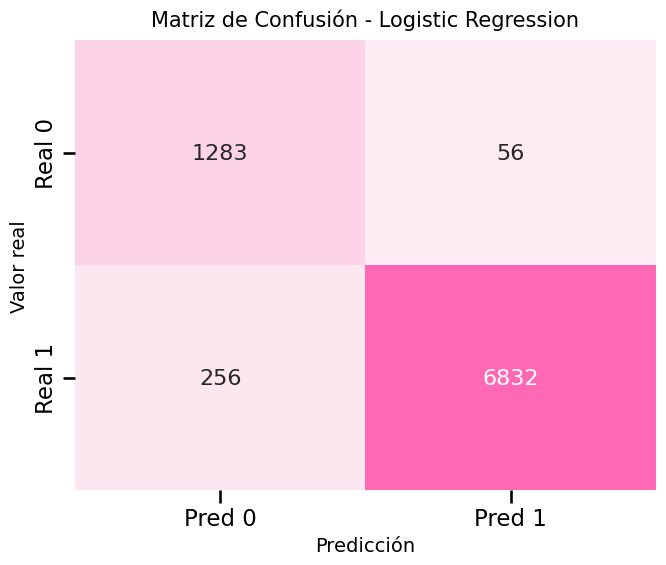

In [13]:
# Se importan las librerias
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap  # Esto crea un mapa de colores personalizado

# Se hace una matriz de confusion con los valores reales y las predicciones
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

# Creamos un degradado personalizado desde un rosado
cmap_rosa = LinearSegmentedColormap.from_list("custom_pink", ["#fcebf2", "hotpink"])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=cmap_rosa,
    cbar=False,
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["Real 0", "Real 1"],
    annot_kws={"size": 16}
)

plt.xlabel("Predicción", fontsize=14)
plt.ylabel("Valor real", fontsize=14)
plt.title(f"Matriz de Confusión - {best_model_name}", fontsize=15, pad=10)

plt.tight_layout()
plt.show()

#### Interpretación del Modelo (Gradient Boosting)

Al analizar la matriz de confusión de nuestro mejor modelo en el conjunto de prueba, podemos extraer las siguientes conclusiones desde la perspectiva de negocio:

* **Verdaderos Positivos (5,863):** El modelo es altamente efectivo detectando los productos exitosos. Acertó casi 6,000 veces cuando un usuario realmente recomendó el producto.
* **Verdaderos Negativos (348):** Logró identificar correctamente una porción de los productos que no serían recomendados.
* **Falsos Positivos (887) - *Área de Riesgo*:** Este es el error más frecuente. El modelo sufre de un "sesgo optimista", prediciendo que un producto será recomendado cuando en realidad el cliente no quedó satisfecho. En un contexto real para Sephora, esto podría traducirse en pérdidas si se invierte presupuesto de marketing en promocionar un producto basándose en esta predicción errónea.
* **Falsos Negativos (178):** El modelo fue pesimista en estos casos, asumiendo que el producto no gustaría, aunque el cliente sí lo recomendó (oportunidades de venta perdidas).

**Conclusión del Trade-Off:**
El modelo actual prioriza encontrar la mayor cantidad de productos recomendados (alta sensibilidad/recall para la clase 1), pero paga el precio de equivocarse frecuentemente con los Falsos Positivos. En la siguiente etapa, buscaremos optimizar los hiperparámetros para reducir este margen de error y lograr un modelo más equilibrado.

### Curva ROC y métrica ROC-AUC

La curva ROC permite evaluar la capacidad del modelo para distinguir entre ambas clases.

Mientras más cercana esté la curva a la esquina superior izquierda, mejor será el rendimiento del clasificador.

El valor ROC-AUC resume esta capacidad en una sola métrica.

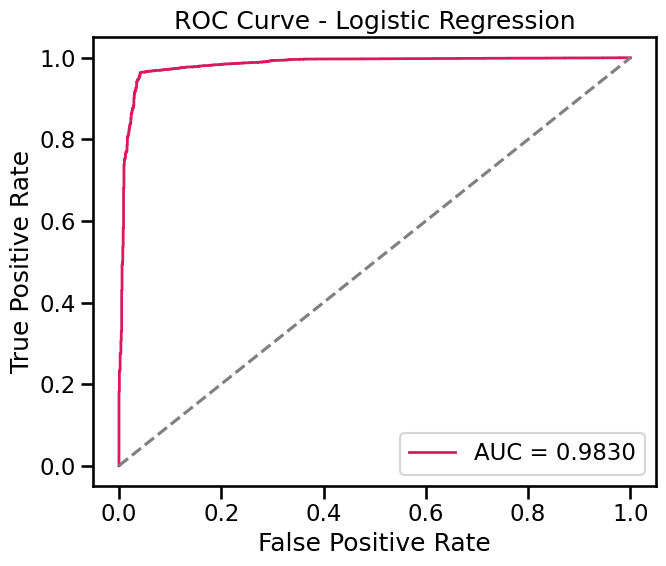

In [15]:
# Se calculan las probabilidades de predicción para la clase positiva (1)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# ROC-AUC, se calcula su valor, ya qie esta mide la capacidad del modelo para distinguir entre las clases, y un valor más alto indica un mejor rendimiento
auc = roc_auc_score(y_test, y_proba)

# Se calculan las coordenadas de la curva ROC, que son el false positive rate (fpr) y el true positive rate (tpr) para diferentes umbrales de clasificación
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Se grafica
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color="#d81b60",
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

#### Interpretación de Resultados

* **Rendimiento Global Sobresaliente:** El modelo obtuvo una métrica **AUC = 0.9830**. Esto significa que existe un **98.3% de probabilidad** de que el modelo asigne una probabilidad de predicción más alta a un caso positivo real que a uno negativo real escogidos al azar.
* **Balance Óptimo de Predicción:** La curva se aproxima de manera muy estrecha a la esquina superior izquierda de la gráfica. Esto demuestra de forma visual que el modelo es capaz de maximizar la tasa de verdaderos positivos (Sensibilidad) manteniendo la tasa de falsos positivos (falsas alarmas) en niveles extremadamente bajos, cercanos a cero.
* **Robustez del Clasificador:** Al alejarse radicalmente de la diagonal gris de referencia ($AUC = 0.50$), se confirma que el rendimiento del algoritmo es altamente efectivo, consistente y significativamente superior a una clasificación aleatoria.

In [ ]:
# Se calcula el test accuracy y el test f1 score para evaluar el rendimiento del modelo en el conjunto de prueba, y se imprimen los resultados
test_accuracy = accuracy_score(y_test, y_pred)

# Esto hace que combine el test accuracy y el test f1 score para evaluar el rendimiento del modelo en el conjunto de prueba, y se imprimen los resultados
test_f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1-score: {test_f1:.4f}")
print(f"Test ROC-AUC: {auc:.4f}")

Test Accuracy: 0.9630
Test F1-score: 0.9777
Test ROC-AUC: 0.9830


#### Interpretación Final del Modelo

El modelo seleccionado presentó un rendimiento sobresaliente sobre el conjunto de prueba, alcanzando un Accuracy de 96.3%, un F1-Score de 97.8% y un ROC-AUC de 98.3%.

Estos resultados indican que el modelo posee una alta capacidad para clasificar correctamente los productos recomendados y no recomendados, manteniendo además un excelente equilibrio entre precisión y sensibilidad.

Asimismo, el elevado valor de ROC-AUC demuestra que el clasificador logra distinguir eficazmente entre ambas clases, evidenciando una sólida capacidad de generalización.